In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('C:/Users/User/PyCharmMiscProject/python/DA_Projects/IMDB/title.combined.csv')
df


,title,titleType,genres,numVotes,year,averageRating
0,The Shawshank Redemption,movie,Drama,3185932,1994,9.3
1,The Dark Knight,movie,"Action,Crime,Drama",3165032,2008,9.1
2,Inception,movie,"Action,Adventure,Sci-Fi",2814573,2010,8.8
3,Game of Thrones,tvSeries,"Action,Adventure,Drama",2611980,2011,9.2
4,Breaking Bad,tvSeries,"Crime,Drama,Thriller",2611328,2008,9.5
...,...,...,...,...,...,...
9994,Blood & Gold,movie,"Action,Drama,War",20178,2023,6.5
9995,Santa Claus Is Comin' to Town,tvMovie,"Adventure,Animation,Comedy",20176,1970,7.7
9996,The Tonight Show Starring Jimmy Fallon,tvSeries,"Comedy,Music,Talk-Show",20176,2014,7.0
9997,Come Play,movie,"Drama,Horror,Mystery",20172,2020,5.8


In [4]:
df.head()

,title,titleType,genres,numVotes,year,averageRating
0,The Shawshank Redemption,movie,Drama,3185932,1994,9.3
1,The Dark Knight,movie,"Action,Crime,Drama",3165032,2008,9.1
2,Inception,movie,"Action,Adventure,Sci-Fi",2814573,2010,8.8
3,Game of Thrones,tvSeries,"Action,Adventure,Drama",2611980,2011,9.2
4,Breaking Bad,tvSeries,"Crime,Drama,Thriller",2611328,2008,9.5


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   title          9999 non-null   str    
 1   titleType      9999 non-null   str    
 2   genres         9998 non-null   str    
 3   numVotes       9999 non-null   int64  
 4   year           9999 non-null   int64  
 5   averageRating  9999 non-null   float64
dtypes: float64(1), int64(2), str(3)
memory usage: 468.8 KB


In [6]:
df.describe()

,numVotes,year,averageRating
count,9.999000e+03,9999.00000,9999.000000
mean,1.215959e+05,2005.50495,6.849405
std,2.002060e+05,16.87822,1.046733
min,2.017100e+04,1902.00000,1.000000
25%,3.065550e+04,1999.00000,6.200000
50%,5.417300e+04,2010.00000,6.900000
75%,1.228770e+05,2018.00000,7.600000
max,3.185932e+06,2026.00000,9.800000


Step 2:Data Cleaning

In [7]:
#Handling Missing Values
df.isnull().sum()

title            0
titleType        0
genres           1
numVotes         0
year             0
averageRating    0
dtype: int64

In [8]:
df[df.isnull().any(axis=1)]#Show rows with null values

,title,titleType,genres,numVotes,year,averageRating
4841,Enes Batur: Imagination or Reality?,movie,NaN,56762,2018,2.0


In [9]:
df[df['genres'].isnull()] # Show null values in a specific column

,title,titleType,genres,numVotes,year,averageRating
4841,Enes Batur: Imagination or Reality?,movie,NaN,56762,2018,2.0


In [15]:
df=df.fillna({'genres':'comedy'}) #filling the value


In [16]:
df.isnull().sum()

title            0
titleType        0
genres           0
numVotes         0
year             0
averageRating    0
dtype: int64

In [17]:
df.duplicated().sum() #any duplicates

np.int64(0)

Removing Extra Spaces

In [23]:
for col in df.select_dtypes(include='str').columns:
    df[col] = df[col].apply(lambda x : x.strip() if isinstance(x, object) else x)
    print(df[col])


0                     The Shawshank Redemption
1                              The Dark Knight
2                                    Inception
3                              Game of Thrones
4                                 Breaking Bad
                         ...                  
9994                              Blood & Gold
9995             Santa Claus Is Comin' to Town
9996    The Tonight Show Starring Jimmy Fallon
9997                                 Come Play
9998                                   Holiday
Name: title, Length: 9999, dtype: str
0          movie
1          movie
2          movie
3       tvSeries
4       tvSeries
          ...   
9994       movie
9995     tvMovie
9996    tvSeries
9997       movie
9998       movie
Name: titleType, Length: 9999, dtype: str
0                            Drama
1               Action,Crime,Drama
2          Action,Adventure,Sci-Fi
3           Action,Adventure,Drama
4             Crime,Drama,Thriller
                   ...            
9994  

Converting Year Column To DateTime

In [30]:
# imdb_data["year"] = pd.to_datetime(imdb_data["year"], format="%Y")

df['year']=pd.to_datetime(df['year'],format='%Y')
print(df['year'])

0      1994-01-01
1      2008-01-01
2      2010-01-01
3      2011-01-01
4      2008-01-01
          ...    
9994   2023-01-01
9995   1970-01-01
9996   2014-01-01
9997   2020-01-01
9998   1938-01-01
Name: year, Length: 9999, dtype: datetime64[us]


Exploratory Data Analysis

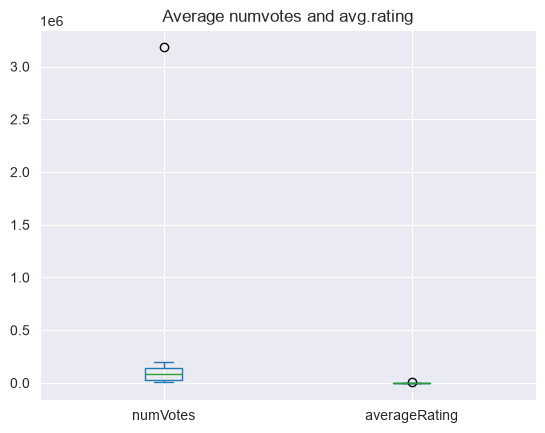

In [41]:
#box plot
df.describe().plot(kind='box')
# plt.figure(figsize=(6,4))
plt.title('Average numvotes and avg.rating')
plt.show()

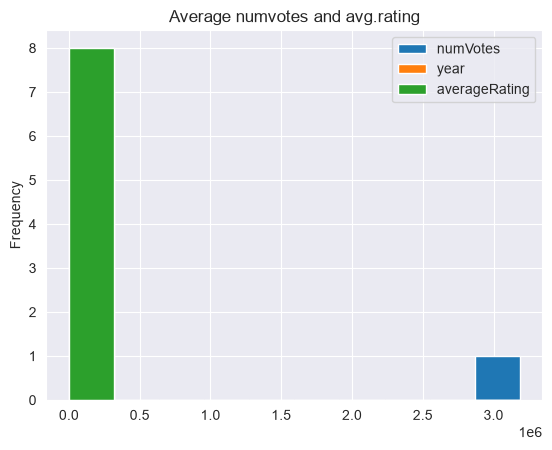

In [80]:
#box plot
df.describe().plot(kind='hist')
# plt.figure(figsize=(6,4))
plt.title('Average numvotes and avg.rating')
plt.show()

In [42]:
for col in df.select_dtypes(include='str').columns: #Count unique values
    print(col, df[col].nunique())

title 9538
titleType 9
genres 466


In [43]:
df['titleType'].unique() #unique values inside the titleType

<StringArray>
[       'movie',     'tvSeries', 'tvMiniSeries',    'tvSpecial',
      'tvMovie',        'video',    'videoGame',        'short',
      'tvShort']
Length: 9, dtype: str

In [44]:
df['titleType'].value_counts() #value counts

titleType
movie           8208
tvSeries        1326
tvMiniSeries     245
video             86
tvMovie           46
videoGame         40
short             35
tvSpecial         11
tvShort            2
Name: count, dtype: int64

In [46]:
df['genres'].unique()

<StringArray>
[                   'Drama',       'Action,Crime,Drama',
  'Action,Adventure,Sci-Fi',   'Action,Adventure,Drama',
     'Crime,Drama,Thriller',   'Adventure,Drama,Sci-Fi',
            'Drama,Romance',              'Crime,Drama',
            'Action,Sci-Fi',  'Adventure,Drama,Fantasy',
 ...
   'Family,Fantasy,Musical',     'Comedy,Crime,History',
  'Drama,Horror,Reality-TV',    'Crime,Sci-Fi,Thriller',
    'Action,Horror,Romance',      'Comedy,Horror,Music',
             'Action,Short',  'Crime,Documentary,Sport',
 'Animation,Fantasy,Horror',    'Action,Horror,Western']
Length: 466, dtype: str

Movies Released Over Time
This visualization shows how movie and TV production has evolved over the years.

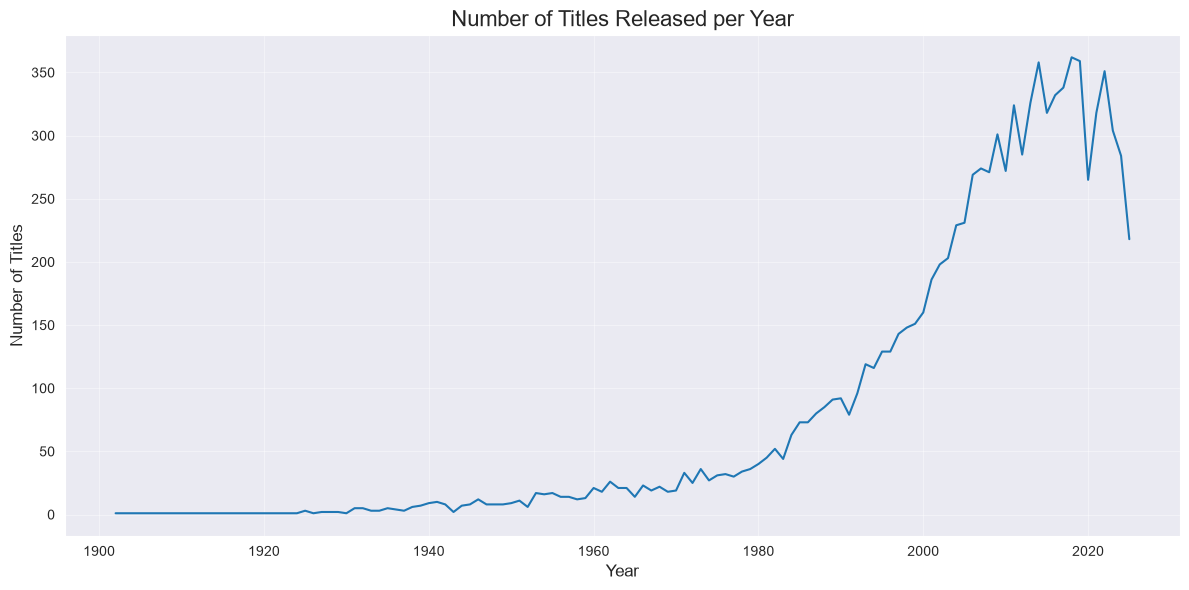

In [47]:
df["year"] = df["year"].dt.year
latest_year = df["year"].max()
filtered_imdb_data = df[df["year"]!=latest_year]
movies_year_data = filtered_imdb_data.groupby("year")["title"].count().sort_index()
plt.figure(figsize=(12,6))
plt.plot(movies_year_data.index,movies_year_data.values)
plt.title("Number of Titles Released per Year",fontsize=16)
plt.xlabel("Year",fontsize=12)
plt.ylabel("Number of Titles",fontsize=12)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

Top 10 Years with the Highest Number of Releases
This analysis identifies the years with the highest number of movie and TV title releases in the dataset. Examining the most productive years helps reveal periods of increased content production and highlights trends in the entertainment industry.

In [50]:
year_count=df['year'].value_counts()
year_count.head()

year
2018    362
2019    359
2014    358
2022    351
2017    338
Name: count, dtype: int64

Top 10 Rated Titles
This analysis identifies the top 10 highest-rated titles in the dataset based on their average IMDb ratings. Ranking titles by their ratings helps highlight the productions that received the strongest audience appreciation. To ensure meaningful results, it is recommended to consider titles with a sufficient number of user votes, as ratings based on only a few votes may not accurately represent overall audience opinion.

In [55]:
titles=df.sort_values(by=['averageRating'],ascending=False)
titles[['title','averageRating','numVotes','year']].head(10)

,title,averageRating,numVotes,year
3684,Red Dead Redemption II,9.8,79774,2018
3322,The Last of Us,9.7,90502,2013
6290,The Witcher 3: Wild Hunt,9.6,39959,2015
8348,God of War: Ragnarök,9.5,26143,2022
8847,Steel Ball Run: JoJo's Bizarre Adventure,9.5,24126,2026
9103,Mass Effect 2,9.5,23151,2010
4,Breaking Bad,9.5,2611328,2008
5599,God of War,9.5,46534,2018
6613,Red Dead Redemption,9.4,37126,2010
1741,Planet Earth II,9.4,175007,2016


Titles with the Most Votes
This analysis identifies the titles that have received the highest number of user votes on IMDb. The number of votes serves as an indicator of a title's popularity and audience engagement. Highly voted titles are typically well-known productions that have attracted a large global audience.

In [56]:
titles=df.sort_values(by=['numVotes'],ascending=False)
titles[['title','averageRating','numVotes','year']].head(10)

,title,averageRating,numVotes,year
0,The Shawshank Redemption,9.3,3185932,1994
1,The Dark Knight,9.1,3165032,2008
2,Inception,8.8,2814573,2010
3,Game of Thrones,9.2,2611980,2011
4,Breaking Bad,9.5,2611328,2008
5,Fight Club,8.8,2605573,1999
6,Interstellar,8.7,2525474,2014
7,Forrest Gump,8.8,2494835,1994
8,Pulp Fiction,8.8,2433805,1994
9,The Matrix,8.7,2245953,1999


Most Common Genres
Many movies and TV shows belong to multiple genres. To analyze genre popularity accurately, the genre values were separated into individual categories before counting their frequencies. This helps identify the genres that appear most frequently in the dataset.

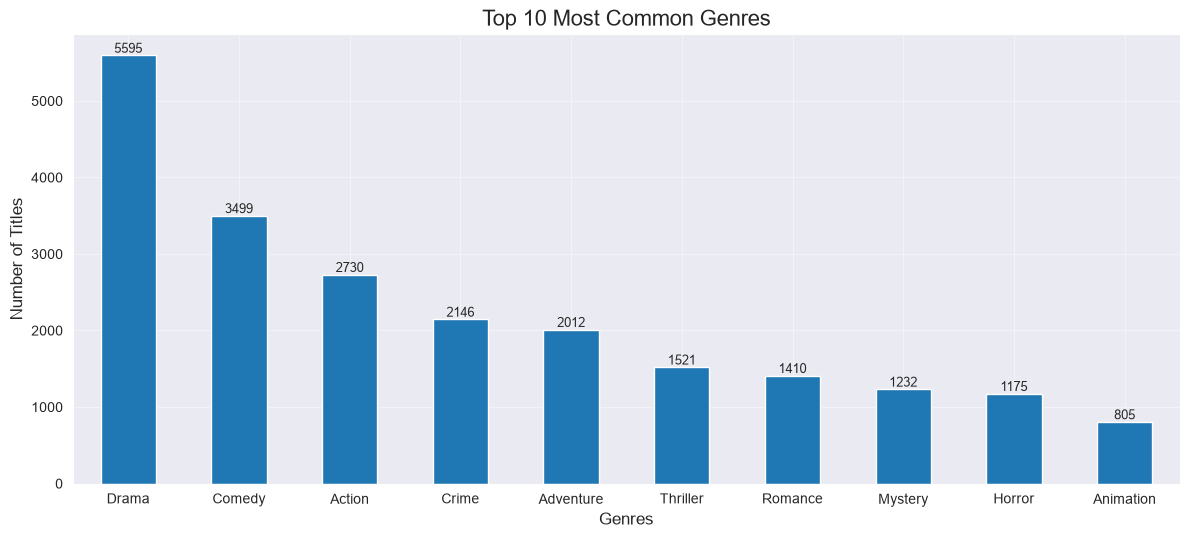

In [61]:
# Splitting the Genre column
genre_split = df["genres"].str.split(",")
# print(genre_split)
# Expanding the genre columns into separate rows
genre_split= genre_split.explode()
# Counting the genres
counting_genre = genre_split.value_counts()
# print(counting_genre)


# Plotting the top 10 genres
top_ten_genres = counting_genre.head(10)
ax = top_ten_genres.plot(kind="bar", figsize=(12,6))

for bar in ax.patches:
     ax.annotate(
         f'{int(bar.get_height())}',
         (bar.get_x() + bar.get_width()/2, bar.get_height()),
         ha='center',
         va='bottom',
         fontsize=9
     )
plt.title("Top 10 Most Common Genres",fontsize=16)
plt.xlabel("Genres",fontsize=12)
plt.ylabel("Number of Titles",fontsize=12)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

Movie vs TV Series
This analysis compares the number of movies and TV series in the dataset. Understanding the distribution of title types provides insight into the overall composition of the IMDb dataset.

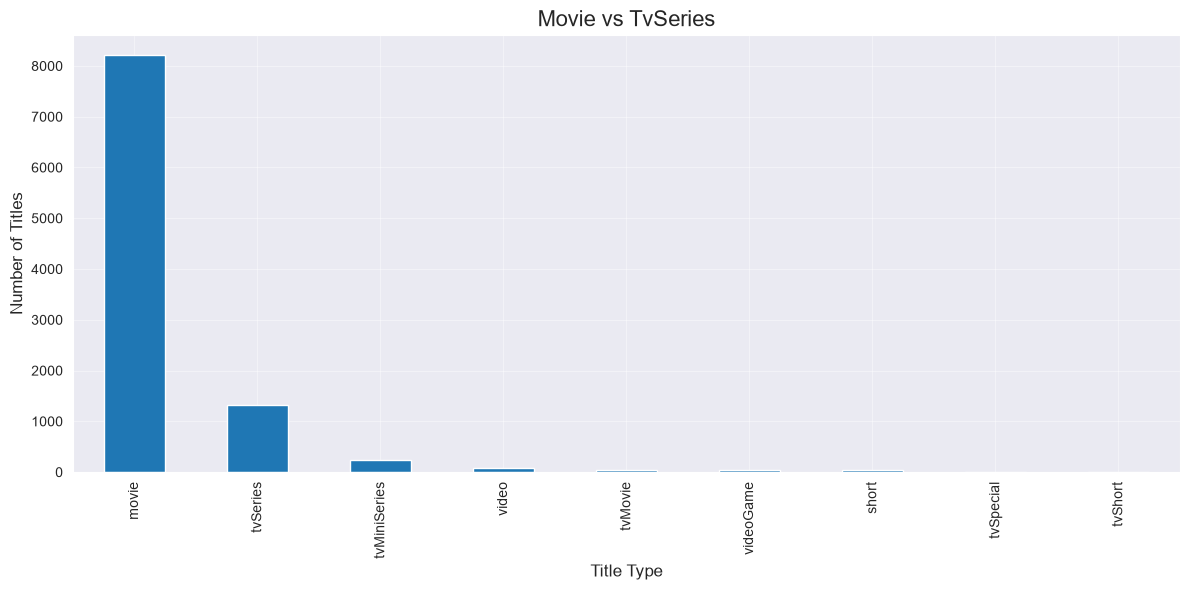

In [63]:
count_movies_tv=df['titleType'].value_counts()
plt.figure(figsize=(12,6))
count_movies_tv.plot(kind="bar", figsize=(12,6))
plt.title("Types of Watching",fontsize=16)
plt.xlabel("Title Type",fontsize=12)
plt.ylabel("Number of Titles",fontsize=12)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

titleType
movie       8208
tvSeries    1326
Name: count, dtype: int64


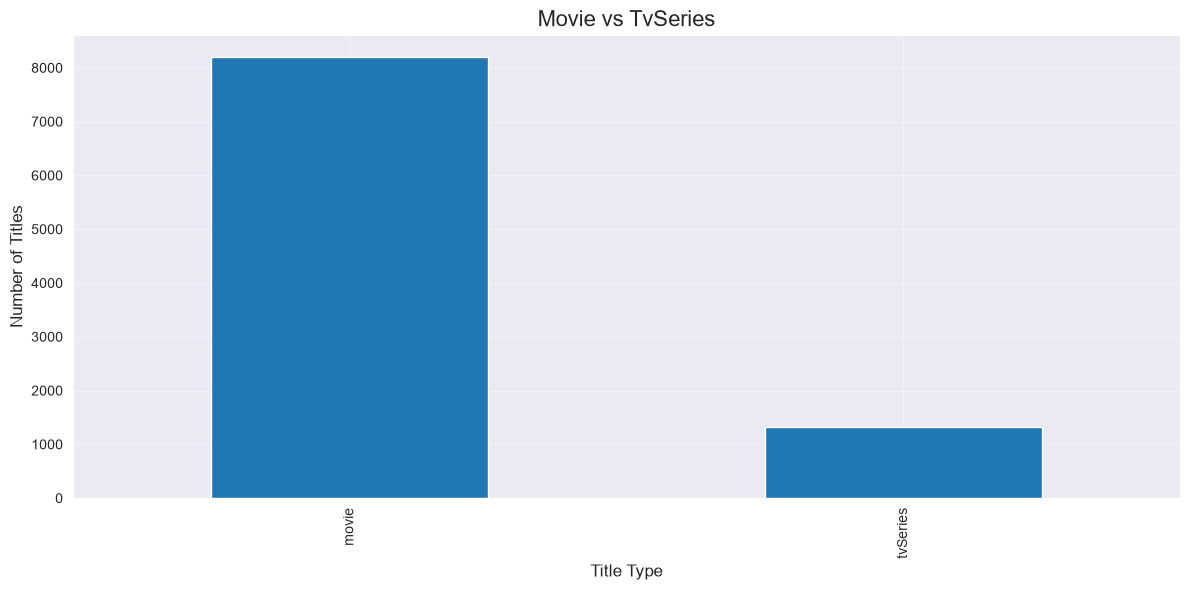

In [74]:

watch=df[df['titleType'].isin(['movie','tvSeries'])]
count_tv=watch['titleType'].value_counts()
print(count_tv)
plt.figure(figsize=(12,6))
count_tv.plot(kind="bar", figsize=(12,6))
plt.title("Movie vs TvSeries",fontsize=16)
plt.xlabel("Title Type",fontsize=12)
plt.ylabel("Number of Titles",fontsize=12)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

Average Rating by Title Type
This analysis compares the average audience ratings of movies and TV series. Calculating the mean rating for each title type helps determine whether viewers tend to rate one type of content more favorably than the other.

titleType
tvSeries    7.767119
movie       6.664864
Name: averageRating, dtype: float64


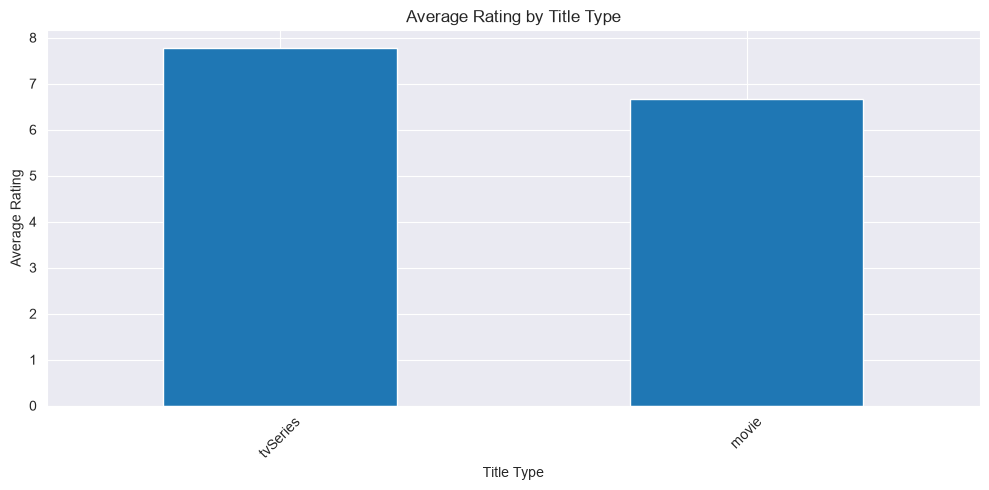

In [76]:
avg_rating = watch.groupby("titleType")["averageRating"].mean().sort_values(ascending=False)
print(avg_rating)

plt.figure(figsize=(10,5))
avg_rating.plot(kind="bar")

plt.title("Average Rating by Title Type")
plt.xlabel("Title Type")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Relationship Between Number of Votes and Average Rating
This analysis investigates whether more popular titles, measured by the number of user votes, tend to receive higher audience ratings. A scatter plot and correlation analysis were used to examine the relationship between popularity and audience satisfaction.

Correlation:0.250


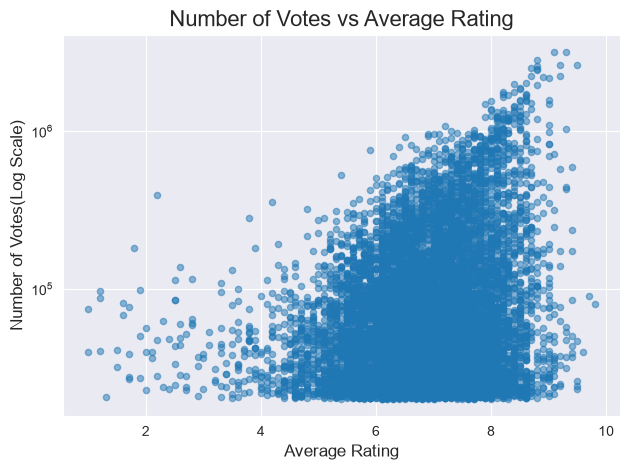

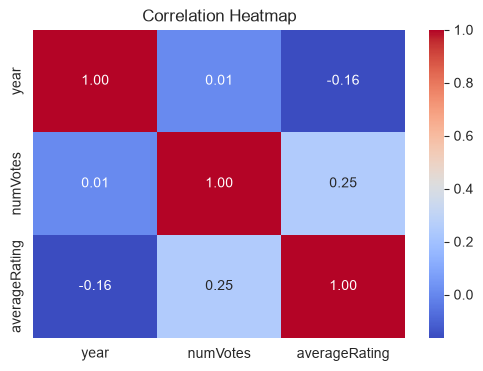

In [77]:
df.plot(kind="scatter",x="averageRating",y="numVotes",alpha=0.5)
plt.yscale("log")
plt.title("Number of Votes vs Average Rating",fontsize=16)
plt.xlabel("Average Rating",fontsize=12)
plt.ylabel("Number of Votes(Log Scale)",fontsize=12)
plt.tight_layout()

correlation = df["numVotes"].corr(df["averageRating"])
print(f"Correlation:{correlation:.3f}")
plt.figure(figsize=(6,4))
sns.heatmap(
    df[
        ["year","numVotes","averageRating"]
    ].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

Outlier Detection - Number of Votes
The Interquartile Range (IQR) method was used to detect outliers in the number of votes. This helps identify titles that received an exceptionally high number of audience votes compared to the rest of the dataset

Number of Outliers of NumVotes: 1073


C:\Users\User\AppData\Local\Temp\ipykernel_21920\1442659024.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["numVotes"],vert=False)


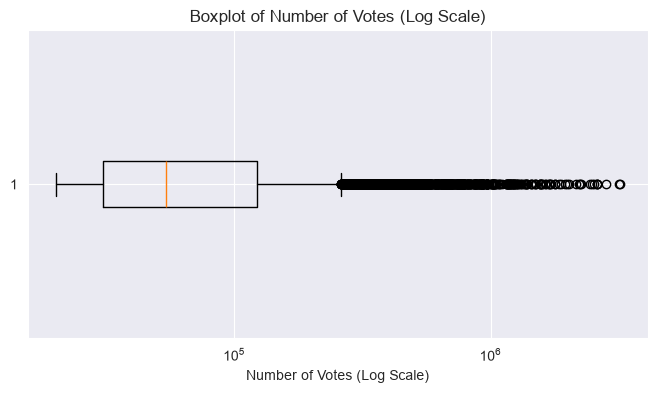

In [78]:
Q1 = df["numVotes"].quantile(0.25)
Q3 = df["numVotes"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

numVotes_outliers = df[(df["numVotes"]<lower_bound) | (df["numVotes"]>upper_bound)]
print(f"Number of Outliers of NumVotes: {len(numVotes_outliers)}")

# Visualization
plt.figure(figsize=(8,4))
plt.boxplot(df["numVotes"],vert=False)
plt.xscale("log")
plt.title("Boxplot of Number of Votes (Log Scale)")
plt.xlabel("Number of Votes (Log Scale)")
plt.show()

Outlier Detection - Average Rating
The distribution of average ratings was examined using a boxplot to identify unusually high or low audience ratings. The IQR method was applied to detect potential outliers.

Number of Outliers of Average Rating: 145


C:\Users\User\AppData\Local\Temp\ipykernel_21920\2052091315.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["averageRating"],vert=False)


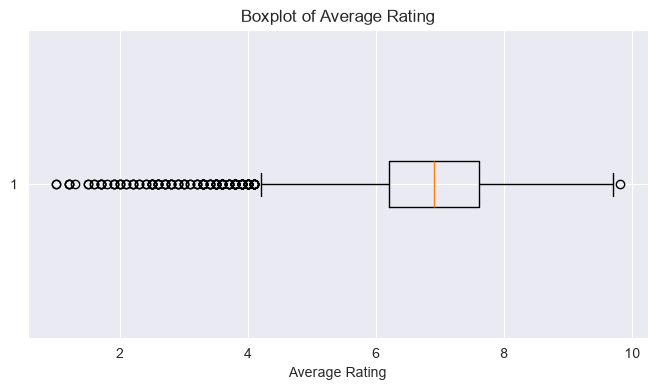

In [79]:
Q1_avg_rating = df["averageRating"].quantile(0.25)
Q3_avg_rating = df["averageRating"].quantile(0.75)
IQR_avg_rating = Q3_avg_rating - Q1_avg_rating

lower_bound = Q1_avg_rating - 1.5*IQR_avg_rating
upper_bound = Q3_avg_rating + 1.5*IQR_avg_rating
average_rating_outliers = df[(df["averageRating"]<lower_bound) | (df["averageRating"]>upper_bound)]
print(f"Number of Outliers of Average Rating: {len(average_rating_outliers)}")

plt.figure(figsize=(8,4))
plt.boxplot(df["averageRating"],vert=False)
plt.title("Boxplot of Average Rating")
plt.xlabel("Average Rating")
plt.show()